# 🛡️ ChurnShield — Model Training Notebook
### E-Commerce Customer Retention Intelligence System
---
This notebook covers:
1. Data Loading & Exploration (EDA)
2. Data Preprocessing
3. Churn Prediction Model (Random Forest + XGBoost)
4. Customer Segmentation (K-Means)
5. CLV Prediction Model
6. Saving all models

In [1]:
import numpy as np
import pandas as pd
print("✅ All good!")

✅ All good!


## 📦 Step 1 — Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)
from sklearn.cluster import KMeans
from xgboost import XGBClassifier

# Plot style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Step 2 — Load Dataset

In [4]:
df = pd.read_csv('../data/churnshield_dataset.csv')

print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 5000 rows × 21 columns


,CustomerID,Gender,Age,Location,MembershipPeriod,PreferredCategory,VisitFrequency,AvgSessionTime,PagesViewed,PurchaseFrequency,...,TotalSpent,LastPurchaseDaysAgo,DiscountUsed,CustomerSatisfaction,ReturnCount,ComplaintHistory,AppUsage,CartAbandonRate,CLV,ChurnRisk
0,C0001,Male,57,Hyderabad,55,Fashion,12,42.44,5,12.04,...,104953.28,168,0,5,6,0,High,0.42,530676.26,0
1,C0002,Female,24,Mumbai,40,Beauty,11,35.61,15,9.58,...,66703.74,107,1,5,3,4,Medium,0.30,311809.97,0
2,C0003,Female,49,Chennai,34,Books,13,7.68,7,13.88,...,76524.71,90,1,4,2,1,High,0.13,237251.46,0
3,C0004,Female,36,Bangalore,34,Beauty,3,38.53,17,8.44,...,28340.45,79,0,1,5,3,Medium,0.67,72444.92,1
4,C0005,Male,23,Bangalore,48,Grocery,27,42.31,16,1.40,...,1123.19,100,0,1,5,3,Low,0.08,3164.33,1


In [5]:
# Basic info
print('📊 Dataset Info:')
print(df.info())
print('\n📊 Missing Values:')
print(df.isnull().sum())
print('\n📊 Basic Statistics:')
df.describe()

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            5000 non-null   object 
 1   Gender                5000 non-null   object 
 2   Age                   5000 non-null   int64  
 3   Location              5000 non-null   object 
 4   MembershipPeriod      5000 non-null   int64  
 5   PreferredCategory     5000 non-null   object 
 6   VisitFrequency        5000 non-null   int64  
 7   AvgSessionTime        5000 non-null   float64
 8   PagesViewed           5000 non-null   int64  
 9   PurchaseFrequency     5000 non-null   float64
 10  AvgOrderValue         5000 non-null   float64
 11  TotalSpent            5000 non-null   float64
 12  LastPurchaseDaysAgo   5000 non-null   int64  
 13  DiscountUsed          5000 non-null   int64  
 14  CustomerSatisfaction  5000 non-null   int64  
 15  Retur

,Age,MembershipPeriod,VisitFrequency,AvgSessionTime,PagesViewed,PurchaseFrequency,AvgOrderValue,TotalSpent,LastPurchaseDaysAgo,DiscountUsed,CustomerSatisfaction,ReturnCount,ComplaintHistory,CartAbandonRate,CLV,ChurnRisk
count,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,40.637000,29.8752,15.037000,23.580240,10.069800,7.707058,4122.063230,31589.045384,90.062200,0.510600,2.985800,5.575400,2.004400,0.502218,78401.329628,0.50000
std,13.407908,17.0586,8.358756,12.489434,5.451905,4.196252,2209.136493,25926.021659,52.402908,0.499938,1.421268,3.435793,1.414207,0.285806,88291.216310,0.50005
min,18.000000,1.0000,1.000000,2.010000,1.000000,0.500000,301.560000,229.780000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,106.470000,0.00000
25%,29.000000,15.0000,8.000000,12.805000,5.000000,4.060000,2270.310000,10277.215000,43.000000,0.000000,2.000000,3.000000,1.000000,0.260000,15567.387500,0.00000
50%,41.000000,30.0000,15.000000,23.395000,10.000000,7.780000,4092.125000,24491.830000,91.000000,1.000000,3.000000,6.000000,2.000000,0.500000,46251.225000,0.50000
75%,52.000000,45.0000,22.000000,34.605000,15.000000,11.370000,6001.490000,46596.965000,136.000000,1.000000,4.000000,9.000000,3.000000,0.750000,110089.590000,1.00000
max,64.000000,59.0000,29.000000,44.990000,19.000000,15.000000,7999.230000,121272.760000,179.000000,1.000000,5.000000,11.000000,4.000000,1.000000,607146.710000,1.00000


## 📊 Step 3 — Exploratory Data Analysis (EDA)

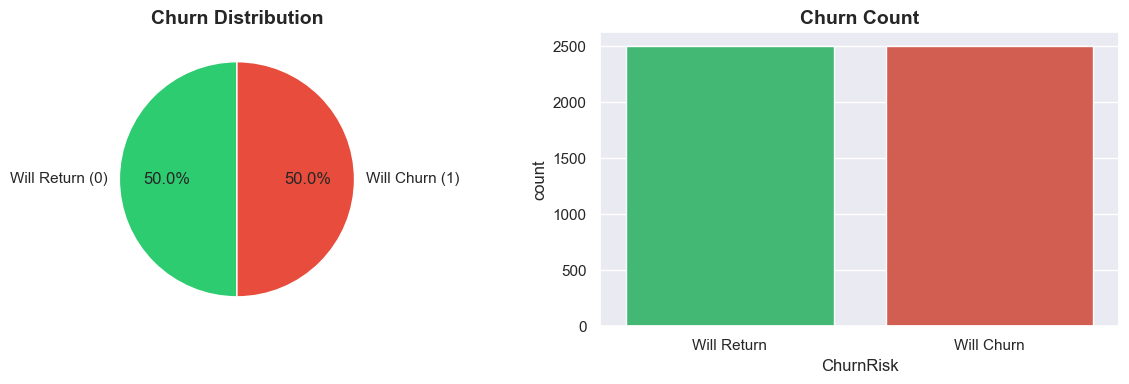

ChurnRisk
0    2500
1    2500
Name: count, dtype: int64


In [6]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['ChurnRisk'].value_counts()
axes[0].pie(
    churn_counts,
    labels=['Will Return (0)', 'Will Churn (1)'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90
)
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')

sns.countplot(data=df, x='ChurnRisk', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Will Return', 'Will Churn'])

plt.tight_layout()
plt.savefig('../data/eda_churn_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(churn_counts)

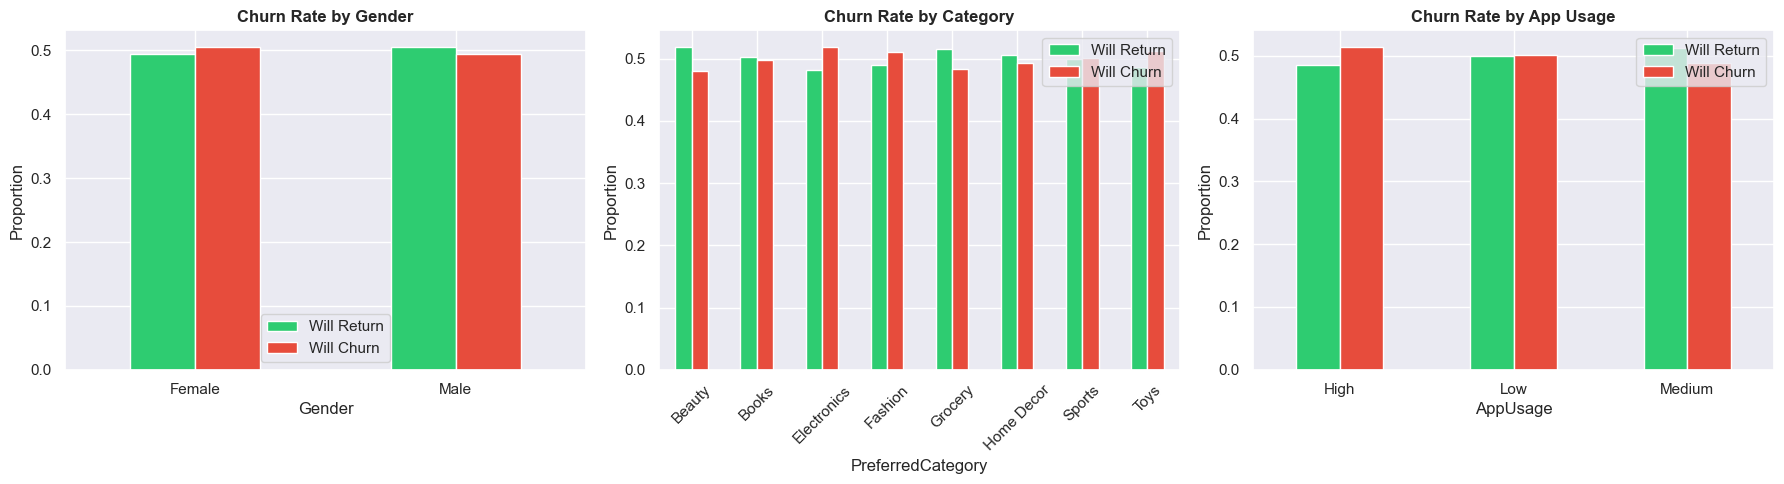

In [7]:
# Churn by key categories
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By Gender
pd.crosstab(df['Gender'], df['ChurnRisk'], normalize='index').plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], rot=0
)
axes[0].set_title('Churn Rate by Gender', fontweight='bold')
axes[0].set_ylabel('Proportion')
axes[0].legend(['Will Return', 'Will Churn'])

# By Preferred Category
pd.crosstab(df['PreferredCategory'], df['ChurnRisk'], normalize='index').plot(
    kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], rot=45
)
axes[1].set_title('Churn Rate by Category', fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].legend(['Will Return', 'Will Churn'])

# By App Usage
pd.crosstab(df['AppUsage'], df['ChurnRisk'], normalize='index').plot(
    kind='bar', ax=axes[2], color=['#2ecc71', '#e74c3c'], rot=0
)
axes[2].set_title('Churn Rate by App Usage', fontweight='bold')
axes[2].set_ylabel('Proportion')
axes[2].legend(['Will Return', 'Will Churn'])

plt.tight_layout()
plt.savefig('../data/eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

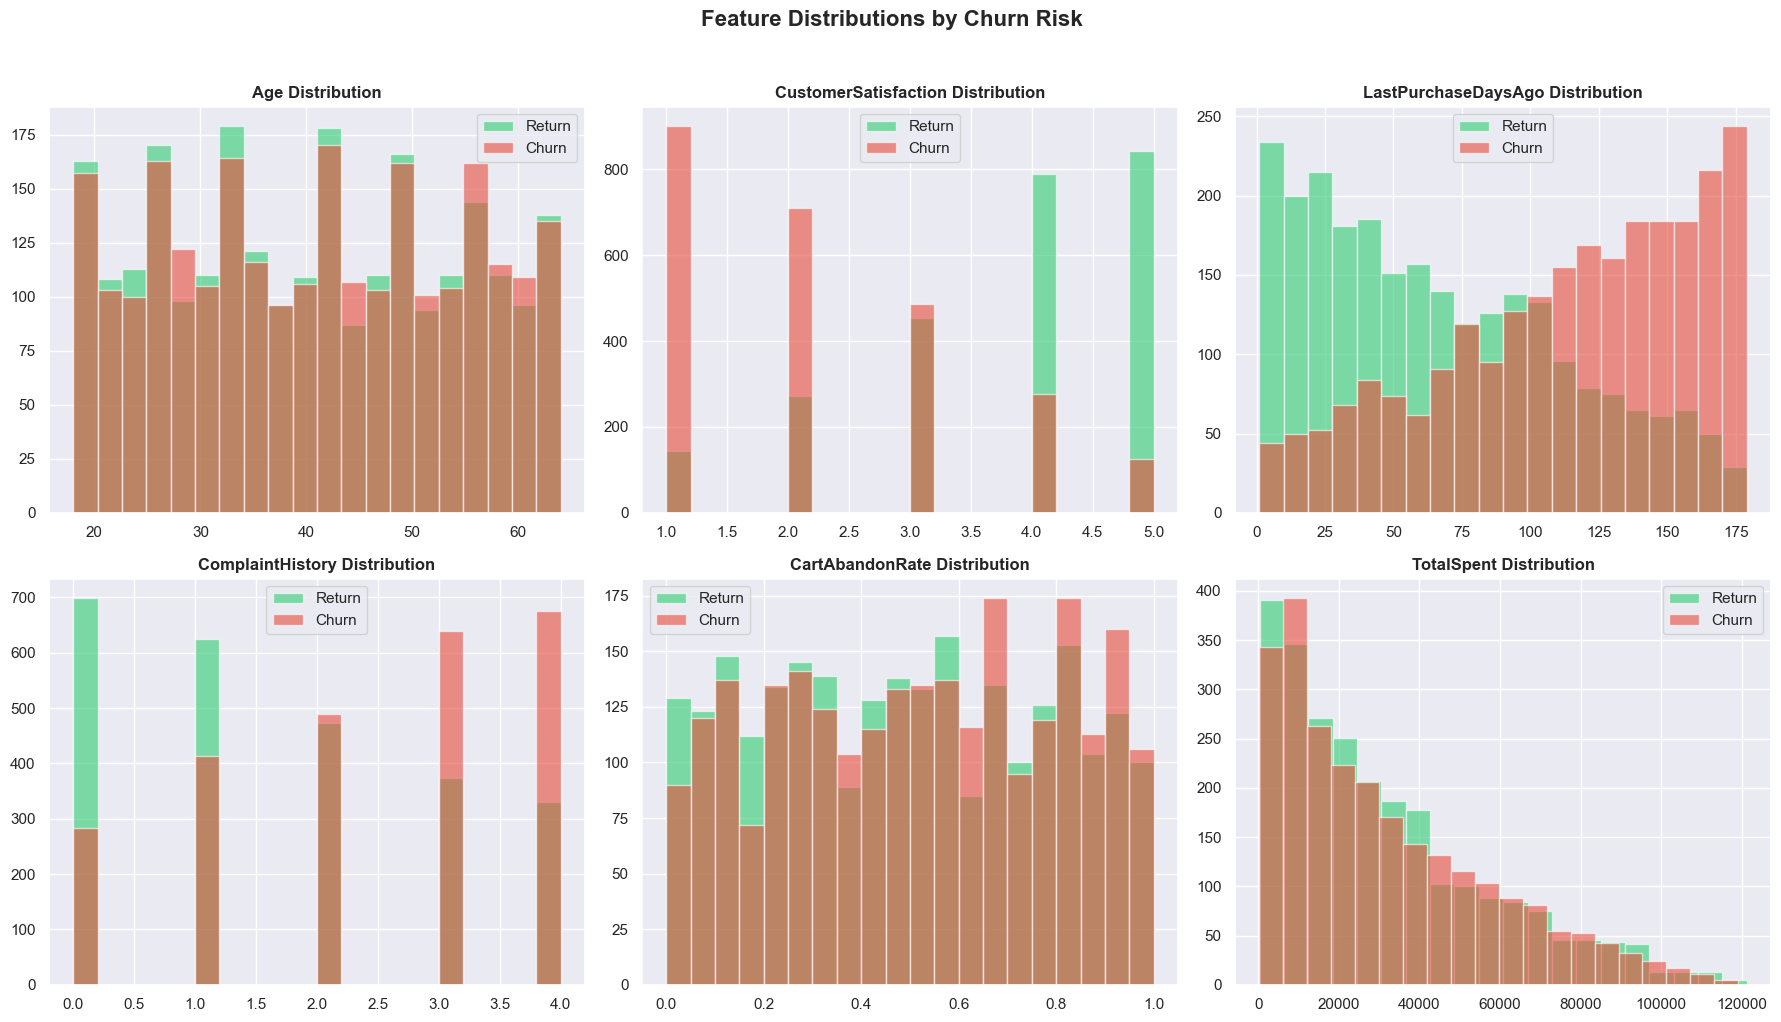

In [8]:
# Numeric feature distributions by churn
numeric_cols = ['Age', 'CustomerSatisfaction', 'LastPurchaseDaysAgo',
                'ComplaintHistory', 'CartAbandonRate', 'TotalSpent']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[df['ChurnRisk'] == 0][col].hist(ax=axes[i], alpha=0.6, color='#2ecc71', label='Return', bins=20)
    df[df['ChurnRisk'] == 1][col].hist(ax=axes[i], alpha=0.6, color='#e74c3c', label='Churn', bins=20)
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].legend()

plt.suptitle('Feature Distributions by Churn Risk', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

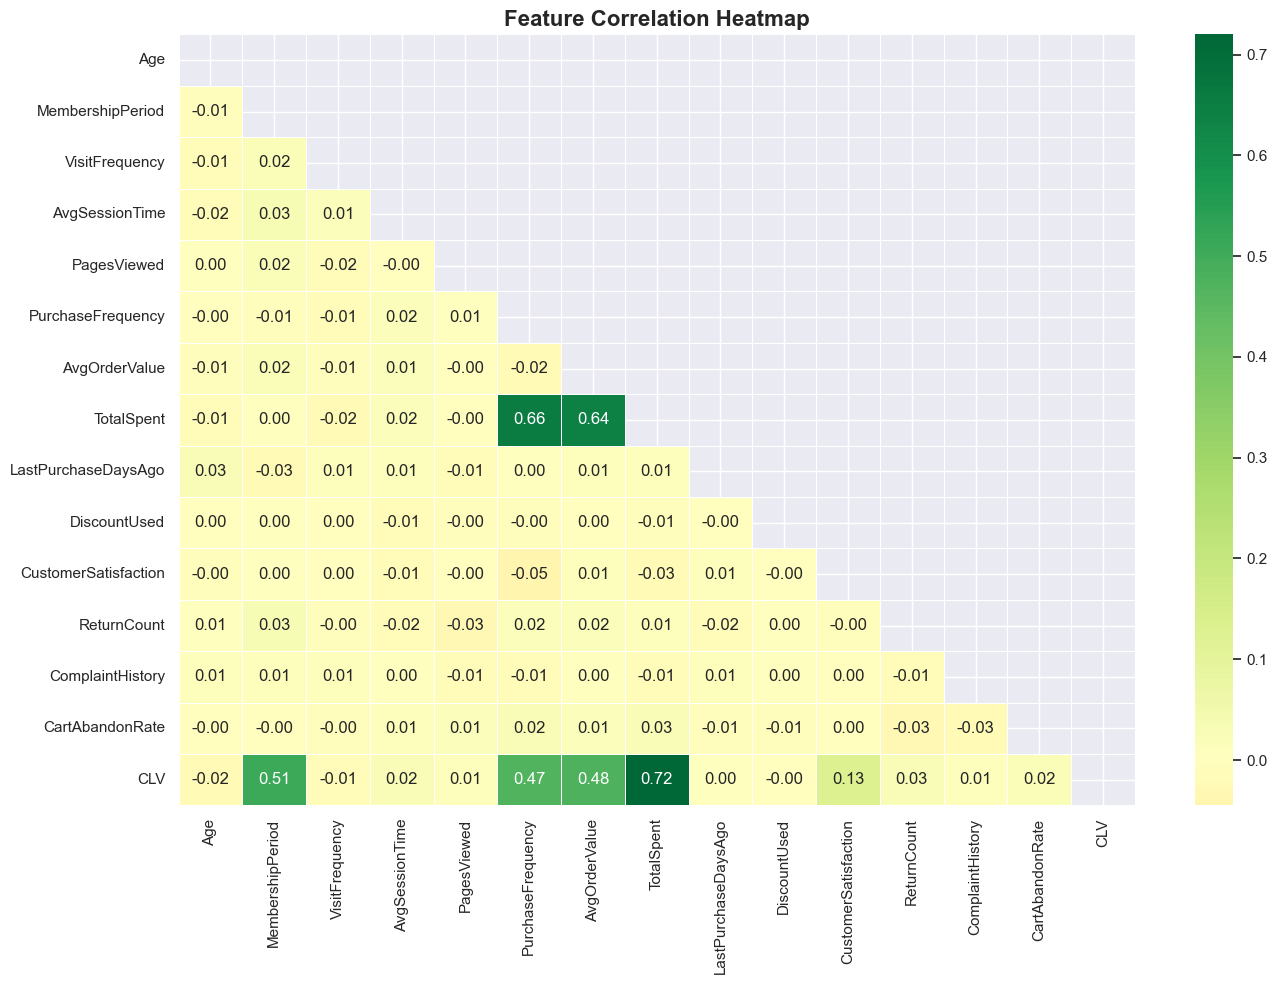

In [9]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number]).drop('ChurnRisk', axis=1)
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚙️ Step 4 — Data Preprocessing

In [10]:
# Work on a copy
data = df.copy()

# Encode categorical columns
le_gender   = LabelEncoder()
le_location = LabelEncoder()
le_category = LabelEncoder()
le_app      = LabelEncoder()

data['Gender_enc']   = le_gender.fit_transform(data['Gender'])
data['Location_enc'] = le_location.fit_transform(data['Location'])
data['Category_enc'] = le_category.fit_transform(data['PreferredCategory'])
data['AppUsage_enc'] = le_app.fit_transform(data['AppUsage'])

# Save encoders
os.makedirs('../models', exist_ok=True)
joblib.dump(le_gender,   '../models/le_gender.pkl')
joblib.dump(le_location, '../models/le_location.pkl')
joblib.dump(le_category, '../models/le_category.pkl')
joblib.dump(le_app,      '../models/le_app.pkl')

print('✅ Encoders saved!')
print('Gender classes:',   list(le_gender.classes_))
print('Location classes:', list(le_location.classes_))
print('Category classes:', list(le_category.classes_))
print('AppUsage classes:', list(le_app.classes_))

✅ Encoders saved!
Gender classes: ['Female', 'Male']
Location classes: ['Ahmedabad', 'Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Jaipur', 'Kolkata', 'Mumbai', 'Pune', 'Surat']
Category classes: ['Beauty', 'Books', 'Electronics', 'Fashion', 'Grocery', 'Home Decor', 'Sports', 'Toys']
AppUsage classes: ['High', 'Low', 'Medium']


In [11]:
# Define features for churn model
CHURN_FEATURES = [
    'Age', 'MembershipPeriod', 'VisitFrequency', 'AvgSessionTime',
    'PagesViewed', 'PurchaseFrequency', 'AvgOrderValue', 'TotalSpent',
    'LastPurchaseDaysAgo', 'DiscountUsed', 'CustomerSatisfaction',
    'ReturnCount', 'ComplaintHistory', 'CartAbandonRate',
    'Gender_enc', 'Location_enc', 'Category_enc', 'AppUsage_enc'
]

X = data[CHURN_FEATURES]
y = data['ChurnRisk']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, '../models/scaler.pkl')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Features ready: {len(CHURN_FEATURES)} features')
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

# Save feature list
joblib.dump(CHURN_FEATURES, '../models/feature_columns.pkl')
print('✅ Scaler & feature list saved!')

✅ Features ready: 18 features
Training set: 4000 samples
Test set:     1000 samples
✅ Scaler & feature list saved!


## 🤖 Step 5 — Churn Prediction Model

In [12]:
# --- Random Forest ---
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_preds)
rf_auc   = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print(f'\n✅ Random Forest Results:')
print(f'   Accuracy : {rf_acc:.4f}')
print(f'   ROC-AUC  : {rf_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, rf_preds, target_names=['Will Return', 'Will Churn']))

Training Random Forest...

✅ Random Forest Results:
   Accuracy : 0.8940
   ROC-AUC  : 0.9595

Classification Report:
              precision    recall  f1-score   support

 Will Return       0.89      0.90      0.89       500
  Will Churn       0.90      0.89      0.89       500

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



In [13]:
# --- XGBoost ---
print('Training XGBoost...')
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_acc   = accuracy_score(y_test, xgb_preds)
xgb_auc   = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

print(f'\n✅ XGBoost Results:')
print(f'   Accuracy : {xgb_acc:.4f}')
print(f'   ROC-AUC  : {xgb_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, xgb_preds, target_names=['Will Return', 'Will Churn']))

Training XGBoost...

✅ XGBoost Results:
   Accuracy : 0.8990
   ROC-AUC  : 0.9665

Classification Report:
              precision    recall  f1-score   support

 Will Return       0.89      0.91      0.90       500
  Will Churn       0.91      0.89      0.90       500

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



In [14]:
# Compare & pick best model
print('\n📊 Model Comparison:')
print(f'   Random Forest — Accuracy: {rf_acc:.4f} | AUC: {rf_auc:.4f}')
print(f'   XGBoost       — Accuracy: {xgb_acc:.4f} | AUC: {xgb_auc:.4f}')

if xgb_auc >= rf_auc:
    best_model = xgb_model
    best_name  = 'XGBoost'
    best_auc   = xgb_auc
    best_acc   = xgb_acc
    best_preds = xgb_preds
else:
    best_model = rf_model
    best_name  = 'Random Forest'
    best_auc   = rf_auc
    best_acc   = rf_acc
    best_preds = rf_preds

print(f'\n🏆 Best Model: {best_name} (AUC: {best_auc:.4f})')
joblib.dump(best_model, '../models/churn_model.pkl')
print(f'✅ Best churn model saved as churn_model.pkl')


📊 Model Comparison:
   Random Forest — Accuracy: 0.8940 | AUC: 0.9595
   XGBoost       — Accuracy: 0.8990 | AUC: 0.9665

🏆 Best Model: XGBoost (AUC: 0.9665)
✅ Best churn model saved as churn_model.pkl


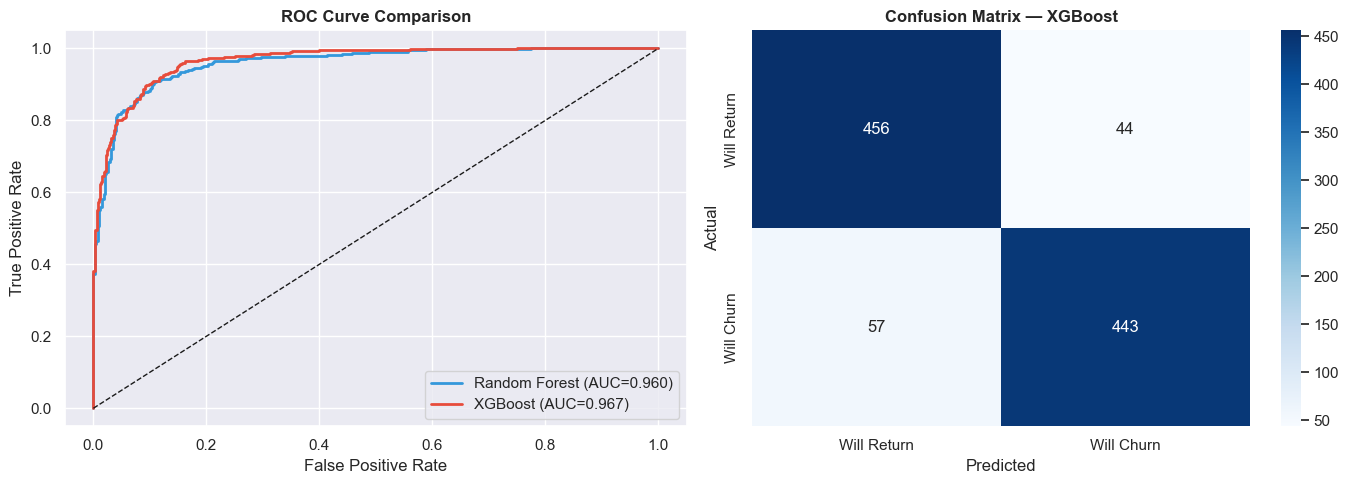

In [15]:
# ROC Curve comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
for model, name, color in [(rf_model, 'Random Forest', '#3498db'), (xgb_model, 'XGBoost', '#e74c3c')]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison', fontweight='bold')
axes[0].legend()

# Confusion matrix of best model
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Will Return', 'Will Churn'],
            yticklabels=['Will Return', 'Will Churn'])
axes[1].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../data/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

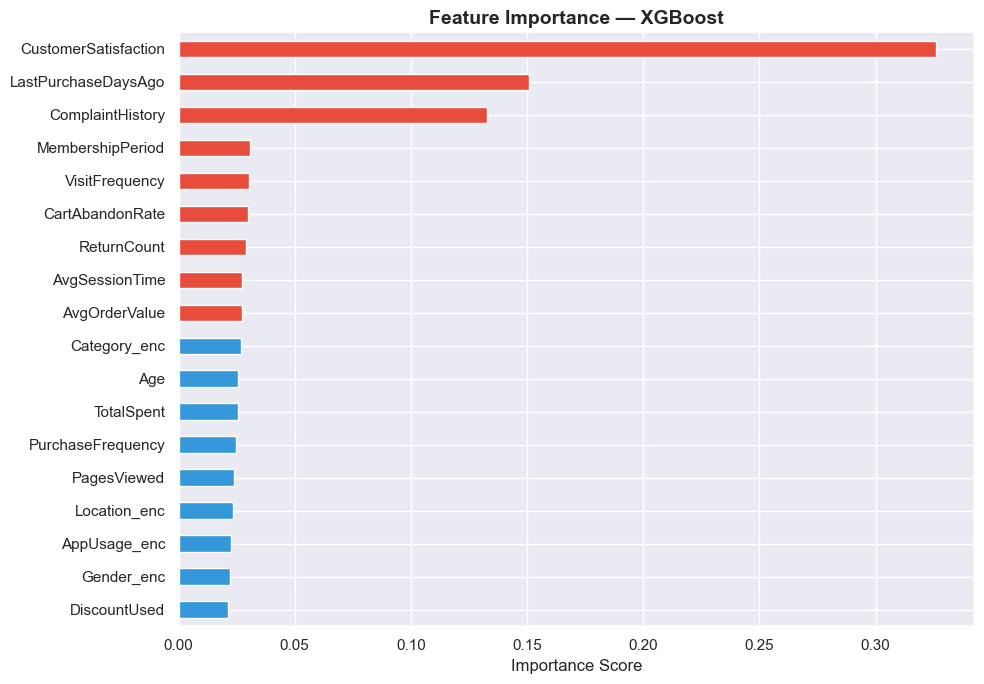

In [16]:
# Feature importance
if best_name == 'Random Forest':
    importances = best_model.feature_importances_
else:
    importances = best_model.feature_importances_

feat_imp = pd.Series(importances, index=CHURN_FEATURES).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if x > feat_imp.median() else '#3498db' for x in feat_imp]
feat_imp.plot(kind='barh', color=colors)
plt.title(f'Feature Importance — {best_name}', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 👥 Step 6 — Customer Segmentation (K-Means)

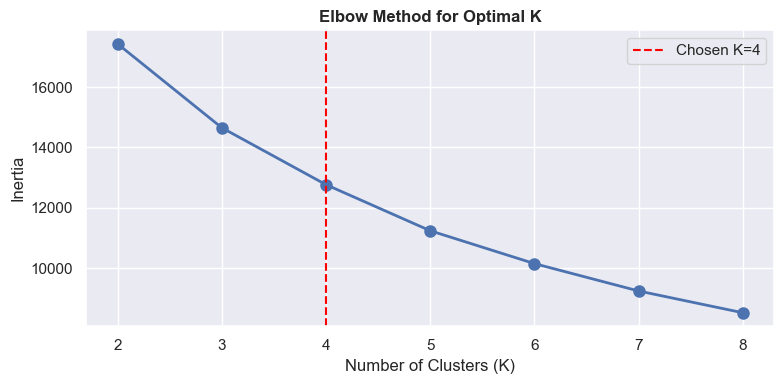

In [17]:
# RFM features for segmentation
rfm = data[['LastPurchaseDaysAgo', 'PurchaseFrequency', 'TotalSpent', 'CustomerSatisfaction', 'CLV']].copy()

rfm_scaler = StandardScaler()
rfm_scaled = rfm_scaler.fit_transform(rfm)
joblib.dump(rfm_scaler, '../models/rfm_scaler.pkl')

# Elbow method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=4, color='red', linestyle='--', label='Chosen K=4')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../data/elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Train K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(rfm_scaled)
joblib.dump(kmeans, '../models/kmeans_model.pkl')

# Analyze clusters to assign segment names
cluster_summary = data.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Recency=('LastPurchaseDaysAgo', 'mean'),
    Avg_Frequency=('PurchaseFrequency', 'mean'),
    Avg_Spent=('TotalSpent', 'mean'),
    Avg_Satisfaction=('CustomerSatisfaction', 'mean'),
    Avg_CLV=('CLV', 'mean'),
    Churn_Rate=('ChurnRisk', 'mean')
).round(2)

print('📊 Cluster Summary:')
print(cluster_summary)

# Assign segment labels based on analysis
# Sort by CLV to assign meaningful labels
clv_order = cluster_summary['Avg_CLV'].rank(ascending=False)
churn_order = cluster_summary['Churn_Rate'].rank(ascending=True)
combined = clv_order + churn_order

sorted_clusters = combined.sort_values().index.tolist()
segment_labels = ['Champions', 'Loyal', 'At-Risk', 'Lost']
segment_map = {cluster: label for cluster, label in zip(sorted_clusters, segment_labels)}

data['Segment'] = data['Cluster'].map(segment_map)
joblib.dump(segment_map, '../models/segment_map.pkl')

print('\n🏷️ Segment Mapping:', segment_map)
print('\n📊 Segment Distribution:')
print(data['Segment'].value_counts())

📊 Cluster Summary:
         Count  Avg_Recency  Avg_Frequency  Avg_Spent  Avg_Satisfaction  \
Cluster                                                                   
0         1261        94.30           3.88   12355.25              1.87   
1         1367        87.12          11.01   41438.14              2.11   
2          791        96.33          11.83   71389.21              3.50   
3         1581        86.09           5.84   18501.23              4.38   

           Avg_CLV  Churn_Rate  
Cluster                         
0         23826.82        0.75  
1         71131.09        0.66  
2        235384.47        0.40  
3         49674.70        0.21  

🏷️ Segment Mapping: {2: 'Champions', 3: 'Loyal', 1: 'At-Risk', 0: 'Lost'}

📊 Segment Distribution:
Segment
Loyal        1581
At-Risk      1367
Lost         1261
Champions     791
Name: count, dtype: int64


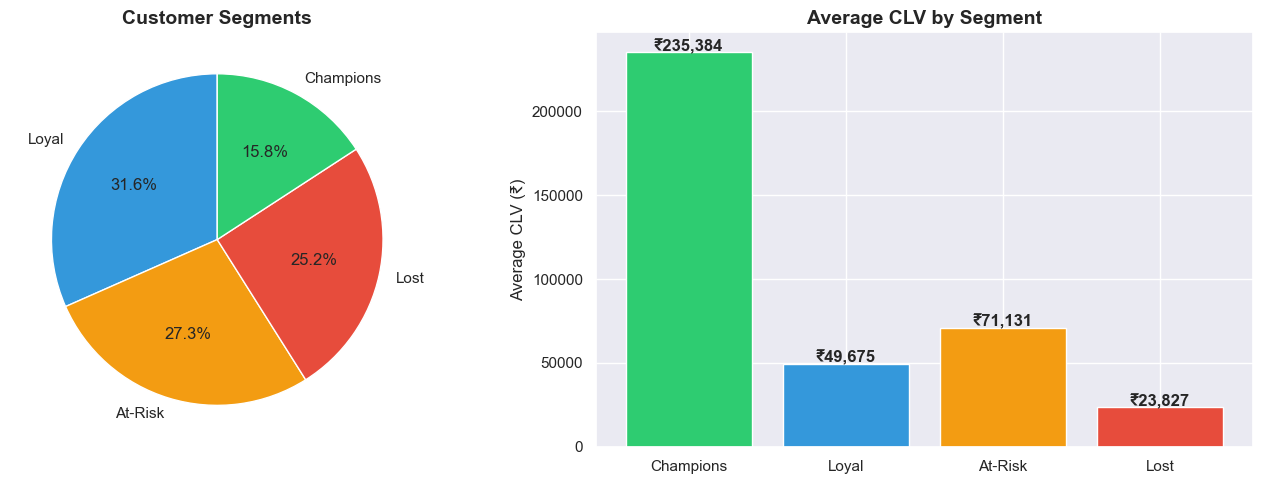

In [19]:
# Visualize segments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segment_colors = {'Champions': '#2ecc71', 'Loyal': '#3498db', 'At-Risk': '#f39c12', 'Lost': '#e74c3c'}
seg_counts = data['Segment'].value_counts()

axes[0].pie(
    seg_counts,
    labels=seg_counts.index,
    autopct='%1.1f%%',
    colors=[segment_colors[s] for s in seg_counts.index],
    startangle=90
)
axes[0].set_title('Customer Segments', fontsize=14, fontweight='bold')

# CLV by segment
seg_clv = data.groupby('Segment')['CLV'].mean().reindex(['Champions', 'Loyal', 'At-Risk', 'Lost'])
bars = axes[1].bar(seg_clv.index, seg_clv.values,
                   color=[segment_colors[s] for s in seg_clv.index])
axes[1].set_title('Average CLV by Segment', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average CLV (₹)')
for bar, val in zip(bars, seg_clv.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'₹{val:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/segments.png', dpi=150, bbox_inches='tight')
plt.show()

## 💰 Step 7 — CLV Prediction Model

In [20]:
# CLV prediction features
CLV_FEATURES = [
    'Age', 'MembershipPeriod', 'PurchaseFrequency',
    'AvgOrderValue', 'TotalSpent', 'CustomerSatisfaction',
    'ReturnCount', 'VisitFrequency', 'DiscountUsed'
]

X_clv = data[CLV_FEATURES]
y_clv = data['CLV']

clv_scaler = StandardScaler()
X_clv_scaled = clv_scaler.fit_transform(X_clv)
joblib.dump(clv_scaler, '../models/clv_scaler.pkl')

X_clv_train, X_clv_test, y_clv_train, y_clv_test = train_test_split(
    X_clv_scaled, y_clv, test_size=0.2, random_state=42
)

# Train Gradient Boosting Regressor
clv_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)
clv_model.fit(X_clv_train, y_clv_train)

clv_preds = clv_model.predict(X_clv_test)
from sklearn.metrics import r2_score, mean_absolute_error
r2  = r2_score(y_clv_test, clv_preds)
mae = mean_absolute_error(y_clv_test, clv_preds)

print(f'✅ CLV Model Results:')
print(f'   R² Score : {r2:.4f}')
print(f'   MAE      : ₹{mae:,.2f}')

joblib.dump(clv_model,  '../models/clv_model.pkl')
joblib.dump(CLV_FEATURES, '../models/clv_feature_columns.pkl')
print('✅ CLV model saved!')

✅ CLV Model Results:
   R² Score : 0.9878
   MAE      : ₹5,908.94
✅ CLV model saved!


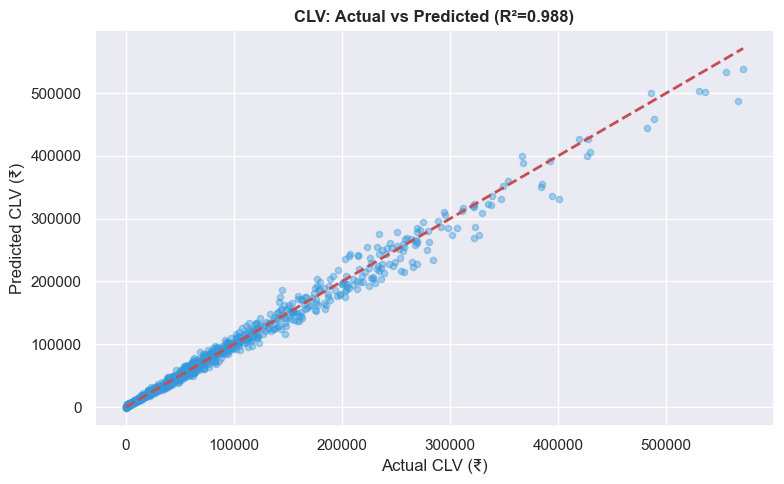

In [21]:
# CLV: Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_clv_test, clv_preds, alpha=0.4, color='#3498db', s=20)
plt.plot([y_clv_test.min(), y_clv_test.max()],
         [y_clv_test.min(), y_clv_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual CLV (₹)')
plt.ylabel('Predicted CLV (₹)')
plt.title(f'CLV: Actual vs Predicted (R²={r2:.3f})', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/clv_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## ✅ Step 8 — Summary

In [22]:
print('=' * 55)
print('        🛡️  ChurnShield — Training Complete!')
print('=' * 55)
print(f'\n🤖 Churn Model  : {best_name}')
print(f'   Accuracy     : {best_acc:.4f}')
print(f'   ROC-AUC      : {best_auc:.4f}')
print(f'\n💰 CLV Model    : Gradient Boosting Regressor')
print(f'   R² Score     : {r2:.4f}')
print(f'   MAE          : ₹{mae:,.2f}')
print(f'\n👥 Segmentation : K-Means (4 clusters)')
print(f'   Segments     : Champions | Loyal | At-Risk | Lost')
print(f'\n📁 Models saved to /models:')
for f in sorted(os.listdir('../models')):
    print(f'   ✅ {f}')
print('\n🚀 Ready to launch the Streamlit app!')
print('=' * 55)

        🛡️  ChurnShield — Training Complete!

🤖 Churn Model  : XGBoost
   Accuracy     : 0.8990
   ROC-AUC      : 0.9665

💰 CLV Model    : Gradient Boosting Regressor
   R² Score     : 0.9878
   MAE          : ₹5,908.94

👥 Segmentation : K-Means (4 clusters)
   Segments     : Champions | Loyal | At-Risk | Lost

📁 Models saved to /models:
   ✅ churn_model.pkl
   ✅ clv_feature_columns.pkl
   ✅ clv_model.pkl
   ✅ clv_scaler.pkl
   ✅ feature_columns.pkl
   ✅ kmeans_model.pkl
   ✅ le_app.pkl
   ✅ le_category.pkl
   ✅ le_gender.pkl
   ✅ le_location.pkl
   ✅ rfm_scaler.pkl
   ✅ scaler.pkl
   ✅ segment_map.pkl

🚀 Ready to launch the Streamlit app!
